In [2]:
# 카테고리별 분석
import pandas as pd

PATH = "00_data/"

payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")

In [3]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [4]:
category_name.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [7]:
products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [6]:
products = products.dropna()

In [8]:
category_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [9]:
import pandas as pd

products_category = pd.merge(products, category_name, on="product_category_name")

In [10]:
products_category

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares
...,...,...,...,...,...,...,...,...,...,...
32322,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,furniture_decor
32323,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,construction_tools_lights
32324,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,bed_bath_table
32325,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0,computers_accessories


In [11]:
products_category_only = products_category[["product_id", "product_category_name_english"]].copy()

In [12]:
products_category_only.head()

,product_id,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares


In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [15]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [16]:
import pandas as pd

products_category_order = pd.merge(products_category_only, order_items, on="product_id")

In [18]:
products_category_order

,product_id,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39
1,3aa071139cb16b67ca9e5dea641aaa2f,art,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82
3,cef67bcfe19066a932b7673e239eb23d,baby,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54
4,9dc1a7de274444849c219cff195d0b71,housewares,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29
...,...,...,...,...,...,...,...,...
111017,83808703fc0706a22e264b9d75f04a2e,computers_accessories,59e88b7d3675e89aceaf86f372d3bc9a,2,4324dd16853115efb0fd9d0d131ba6f4,2018-01-10 03:32:09,29.90,16.11
111018,83808703fc0706a22e264b9d75f04a2e,computers_accessories,6e4465d771f02e4fe335225de3c6c043,1,4324dd16853115efb0fd9d0d131ba6f4,2018-03-14 02:30:48,29.90,23.28
111019,83808703fc0706a22e264b9d75f04a2e,computers_accessories,6e4465d771f02e4fe335225de3c6c043,2,4324dd16853115efb0fd9d0d131ba6f4,2018-03-14 02:30:48,29.90,23.28
111020,83808703fc0706a22e264b9d75f04a2e,computers_accessories,6e4465d771f02e4fe335225de3c6c043,3,4324dd16853115efb0fd9d0d131ba6f4,2018-03-14 02:30:48,29.90,23.28


In [ ]:
# rename() : 이미 연결된 특정 데이터 프레임 내 특정 컬럼명 (필드명)만 수정.변경하고자 할 때 사용가능한 메서드
# grouping을 할 때, aggregate() | agg() -> 좌측 메서드를 활용해서 연산을 처리할 수도 있음
# pandas -> groupby().sum() | count() -> 특정 요소의 그룹화 진행 -> 그룹 외 요소들의 연산집계 단일화된 연산처리
# 복수의 연산처리 -> 특정 요소의 합도 구하고, 최소값도 구하고 싶음

In [19]:
# aggregate() => 집계하다 (MySQL)

import pandas as pd

df = pd.DataFrame({
    "미국": [2.1, 2.2, 2.3],
    "한국": [0.4, 0.5, 0.45],
    "중국": [10, 13, 15],
})

df

,미국,한국,중국
0,2.1,0.40,10
1,2.2,0.50,13
2,2.3,0.45,15


In [20]:
df.aggregate(["sum", "min"])

,미국,한국,중국
sum,6.6,1.35,38
min,2.1,0.40,10


In [21]:
df.agg(["sum", "min"])

,미국,한국,중국
sum,6.6,1.35,38
min,2.1,0.40,10


In [22]:
df.agg({"미국": "count", "한국": "sum"})

미국    3.00
한국    1.35
dtype: float64

In [30]:
df.agg("mean", axis="columns") # columns => 열 => 행단위로 평균값을 집계 => 1 VS 0, rows => 행방향 => 열단위로 연산

0    4.166667
1    5.233333
2    5.916667
dtype: float64

In [31]:
import pandas as pd

df = pd.DataFrame({
    "년도": [2000, 2010, 2020, 2000, 2000, 2020],
    "미국": [2.1, 2.2, 2.3, 3.1, 4.1, 5.1],
    "한국": [0.4, 0.5, 0.45, 0.7, 0.9, 1.2],
    "중국": [10, 13, 15, 12, 45, 56],
})

df

,년도,미국,한국,중국
0,2000,2.1,0.40,10
1,2010,2.2,0.50,13
2,2020,2.3,0.45,15
3,2000,3.1,0.70,12
4,2000,4.1,0.90,45
5,2020,5.1,1.20,56


In [32]:
df.groupby("년도").sum()

,미국,한국,중국
년도,,,
2000,9.3,2.00,67
2010,2.2,0.50,13
2020,7.4,1.65,71


In [34]:
df.groupby("년도").agg({"미국": "sum"})

,미국
년도,
2000,9.3
2010,2.2
2020,7.4


In [35]:
df.groupby("년도").agg({"미국": "sum", "한국": "mean"})

,미국,한국
년도,,
2000,9.3,0.666667
2010,2.2,0.500000
2020,7.4,0.825000


In [38]:
products_category_order = products_category_order.groupby("product_category_name_english").aggregate({"order_id": "count"}).rename(columns={"order_id": "order_count"})

In [39]:
products_category_order

,order_count
product_category_name_english,
agro_industry_and_commerce,212
air_conditioning,297
art,209
arts_and_craftmanship,24
audio,364
...,...
stationery,2517
tablets_printing_image,83
telephony,4545


In [49]:
products_category_order = products_category_order.sort_values(by="order_count", ascending=False)
products_category_order

,order_count
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
...,...
arts_and_craftmanship,24
la_cuisine,14
cds_dvds_musicals,14


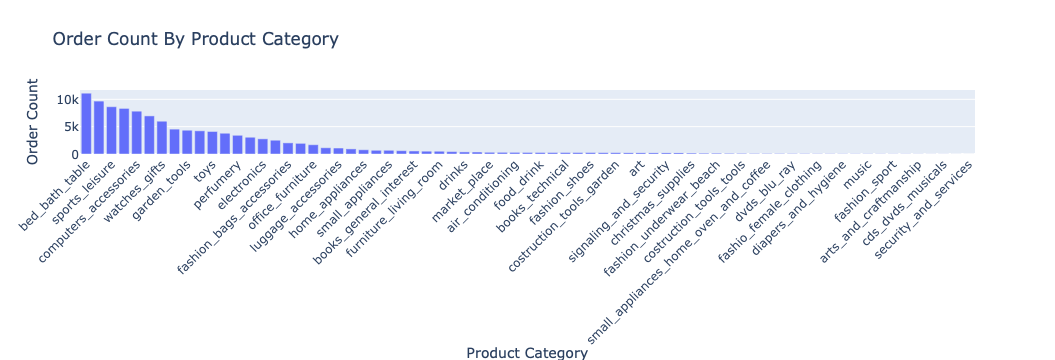

In [43]:
import plotly.express as px

fig = px.bar(
    x = products_category_order.index,
    y = products_category_order["order_count"],
    title = "Order Count By Product Category",
    labels = {
        "x": "Product Category",
        "y": "Order Count"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

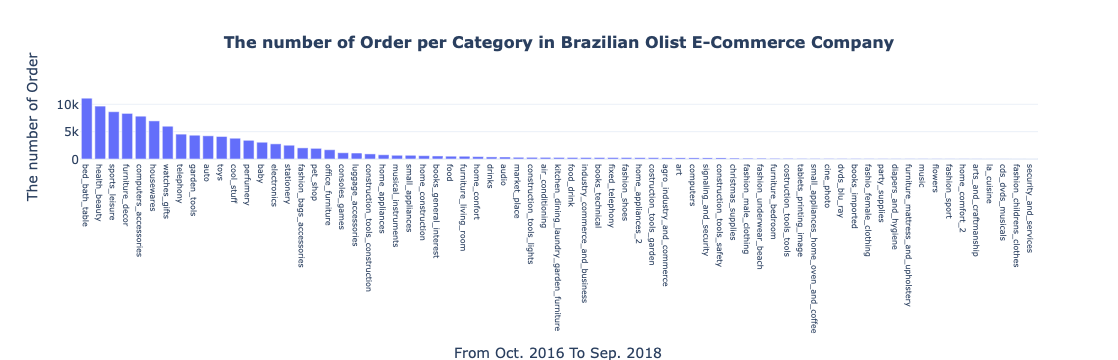

In [48]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x = products_category_order.index,
        y = products_category_order["order_count"]
    )
)

fig.update_layout(
    {
        "title": {
            "text": "<b>The number of Order per Category in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Oct. 2016 To Sep. 2018",
            "showticklabels": True,
            "tickfont": {
                "size": 8
            }
        },
        "yaxis": {
            "title": "The number of Order"
        },
        "template": "plotly_white"
    }
)

fig.show()

In [50]:
products_category_order_top = products_category_order[products_category_order["order_count"] >= 1000]

In [51]:
products_category_order_top

,order_count
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347


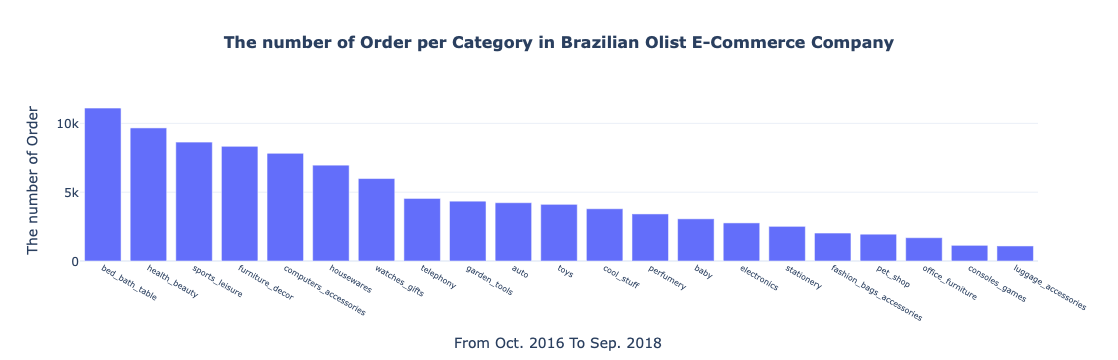

In [52]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x = products_category_order_top.index,
        y = products_category_order_top["order_count"]
    )
)

fig.update_layout(
    {
        "title": {
            "text": "<b>The number of Order per Category in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Oct. 2016 To Sep. 2018",
            "showticklabels": True,
            "tickfont": {
                "size": 8
            }
        },
        "yaxis": {
            "title": "The number of Order"
        },
        "template": "plotly_white"
    }
)

fig.show()